###Part I: Hidden Markov Models (HMM)

Question 1: Training

In [7]:
!pip install hmmlearn librosa joblib -q

Download Public Spoken Digit Dataset

In [8]:
!git clone https://github.com/Jakobovski/free-spoken-digit-dataset.git

Cloning into 'free-spoken-digit-dataset'...
remote: Enumerating objects: 4260, done.
remote: Counting objects: 100% (48/48), done.
remote: Compressing objects: 100% (40/40), done.
remote: Total 4260 (delta 25), reused 8 (delta 8), pack-reused 4212 (from 1)
Receiving objects: 100% (4260/4260), 30.38 MiB | 22.13 MiB/s, done.
Resolving deltas: 100% (129/129), done.


In [2]:
import os
import numpy as np
import librosa
import joblib
from hmmlearn.hmm import GMMHMM

In [9]:
DATASET_PATH = "/content/free-spoken-digit-dataset/recordings"

Extract 13-D MFCC Features

In [10]:
def extract_mfcc(file_path, n_mfcc=13):
    signal, sr = librosa.load(file_path, sr=None)

    mfcc = librosa.feature.mfcc(
        y=signal,
        sr=sr,
        n_mfcc=n_mfcc,
        n_fft=512,
        hop_length=160,
        win_length=400
    )

    return mfcc.T

In [11]:
digit_files = {i: [] for i in range(10)}

for file in os.listdir(DATASET_PATH):
    if file.endswith(".wav"):
        digit = int(file[0])
        digit_files[digit].append(os.path.join(DATASET_PATH, file))

Left-to-Right Transition Matrix

In [12]:
def create_left_to_right_transmat(n_states):
    A = np.zeros((n_states, n_states))

    for i in range(n_states):
        if i == n_states - 1:
            A[i, i] = 1.0
        else:
            A[i, i] = 0.6
            A[i, i+1] = 0.4

    return A

Prepare Training Data for Each Digit

In [13]:
digit_sequences = {}

for digit in range(10):

    sequences = []
    lengths = []

    for file_path in digit_files[digit]:

        mfcc = extract_mfcc(file_path)

        sequences.append(mfcc)
        lengths.append(len(mfcc))

    X = np.vstack(sequences)

    digit_sequences[digit] = {
        "X": X,
        "lengths": lengths
    }

print("MFCC extraction complete.")

MFCC extraction complete.


Train 10 Separate GMM-HMMs

In [14]:
N_STATES = 5
N_MIXTURES = 3
MAX_ITER = 100
TOL = 1e-4

hmm_models = {}

In [15]:
for digit in range(10):

    print("="*50)
    print(f"Training HMM for Digit {digit}")
    print("="*50)

    model = GMMHMM(
        n_components=N_STATES,
        n_mix=N_MIXTURES,
        covariance_type='diag',
        n_iter=MAX_ITER,
        tol=TOL,
        verbose=True,
        init_params='mcw'   # preserve custom pi and A
    )

    # Initial State Distribution π
    startprob = np.zeros(N_STATES)
    startprob[0] = 1.0

    # Left-to-Right Transition Matrix A
    transmat = create_left_to_right_transmat(N_STATES)

    model.startprob_ = startprob
    model.transmat_ = transmat

    # Baum-Welch / EM Training
    model.fit(
        digit_sequences[digit]["X"],
        digit_sequences[digit]["lengths"]
    )

    hmm_models[digit] = model

print("Training Completed.")

Training HMM for Digit 0


         1 -445221.62251896             +nan
         2 -426572.85055354  +18648.77196542
         3 -421852.04540301   +4720.80515054
         4 -419648.67864108   +2203.36676192
         5 -418651.14887337    +997.52976772
         6 -418068.23398455    +582.91488881
         7 -417617.85831635    +450.37566821
         8 -417382.90282172    +234.95549463
         9 -417288.61455166     +94.28827006
        10 -417246.05877912     +42.55577254
        11 -417224.63775237     +21.42102675
        12 -417211.86327788     +12.77447449
        13 -417202.49794570      +9.36533218
        14 -417194.67436228      +7.82358342
        15 -417186.35666657      +8.31769572
        16 -417175.81501207     +10.54165450
        17 -417165.64636184     +10.16865023
        18 -417153.21437723     +12.43198461
        19 -417136.73614299     +16.47823423
        20 -417117.22229800     +19.51384499
        21 -417099.30109288     +17.92120513
        22 -417086.39774188     +12.90335100
        23

Training HMM for Digit 1


         1 -361560.33788487             +nan
         2 -349486.68736327  +12073.65052159
         3 -345044.17708215   +4442.51028112
         4 -342499.48476811   +2544.69231404
         5 -341227.74148967   +1271.74327844
         6 -340337.02711347    +890.71437620
         7 -339786.28014847    +550.74696500
         8 -339505.79378584    +280.48636263
         9 -339337.38264208    +168.41114376
        10 -339226.83074312    +110.55189896
        11 -339156.33735233     +70.49339079
        12 -339105.28706158     +51.05029075
        13 -339078.90811891     +26.37894267
        14 -339064.81759925     +14.09051966
        15 -339055.18909818      +9.62850107
        16 -339047.24197255      +7.94712563
        17 -339039.80747462      +7.43449793
        18 -339033.21166851      +6.59580611
        19 -339027.54468601      +5.66698250
        20 -339021.96261370      +5.58207230
        21 -339015.24932732      +6.71328638
        22 -339005.34131151      +9.90801581
        23

Training HMM for Digit 2


...

         1 -355871.13265405             +nan
         2 -340884.20225727  +14986.93039678
         3 -338421.52501547   +2462.67724180
         4 -337797.38547479    +624.13954068
         5 -337508.25582323    +289.12965156
         6 -337278.59180362    +229.66401961
         7 -337066.12784667    +212.46395696
         8 -336806.51034074    +259.61750593
         9 -336584.75565082    +221.75468992
        10 -336446.83823780    +137.91741302
        11 -336323.72115349    +123.11708431
        12 -336164.34808644    +159.37306705
        13 -335992.85775926    +171.49032718
        14 -335865.43735742    +127.42040184
        15 -335781.71793302     +83.71942440
        16 -335691.56815833     +90.14977469
        17 -335583.56512333    +108.00303500
        18 -335520.74179938     +62.82332395
        19 -335487.97657800     +32.76522139
        20 -335470.54543844     +17.43113956
        21 -335458.48686604     +12.05857240
        22 -335447.99704875     +10.48981729
        23

Training HMM for Digit 9


         1 -430505.90888493             +nan
         2 -410497.69226222  +20008.21662271
         3 -406415.75908083   +4081.93318139
         4 -405508.92218493    +906.83689590
         5 -405181.64161004    +327.28057488
         6 -405004.38720357    +177.25440647
         7 -404887.32629217    +117.06091140
         8 -404796.17163119     +91.15466098
         9 -404691.80875421    +104.36287699
        10 -404566.38299404    +125.42576017
        11 -404488.23040093     +78.15259311
        12 -404447.46526480     +40.76513613
        13 -404416.67700040     +30.78826440
        14 -404376.80886750     +39.86813290
        15 -404333.53751885     +43.27134865
        16 -404293.36189302     +40.17562583
        17 -404255.74130511     +37.62058791
        18 -404220.57505361     +35.16625150
        19 -404188.93377462     +31.64127899
        20 -404165.69786755     +23.23590707
        21 -404146.55462534     +19.14324221
        22 -404123.03292623     +23.52169911
        23

Training Completed.


        54 -403736.60932541      +0.00007591


Save Trained Models

In [16]:
joblib.dump(hmm_models, "trained_hmm_models.pkl")

['trained_hmm_models.pkl']

Initial Probabilities

In [17]:
print(hmm_models[0].startprob_)

[1. 0. 0. 0. 0.]


Transition Matrix

In [18]:
print(hmm_models[0].transmat_)

[[0.83737857 0.16262143 0.         0.         0.        ]
 [0.         0.80809972 0.19190028 0.         0.        ]
 [0.         0.         0.81582935 0.18417065 0.        ]
 [0.         0.         0.         0.91562169 0.08437831]
 [0.         0.         0.         0.         1.        ]]


GMM Emission Parameters

In [19]:
print(hmm_models[0].means_)
print(hmm_models[0].covars_)
print(hmm_models[0].weights_)

[[[-4.67405660e+02  1.04870421e+02 -3.97978032e+01 -6.81551069e-01
   -2.15529546e+01 -3.98602899e+00 -4.39496055e+01 -2.21675604e+01
   -1.00450326e+01  2.71836027e+00 -1.38128101e+01 -3.17445021e+00
   -9.38842146e-01]
  [-5.46553739e+02  4.72188007e+01  4.32767674e+01  2.35100113e+01
   -1.49380987e+01 -1.39048132e+01 -1.49308942e+01 -1.85627122e+01
   -1.86643305e+01 -4.18787275e+00 -5.64823352e+00 -3.83474649e+00
   -2.76870131e+00]
  [-5.60249111e+02  9.12149745e+01 -1.87167106e+01  2.95596925e+01
   -1.73362656e+01 -4.54686262e+01  2.41986959e+00 -8.85738917e+00
   -9.75358301e+00  2.18864998e-01 -5.49405638e+00  2.64700174e+00
   -1.79413366e+01]]

 [[-5.36183421e+02  9.30181190e+01  3.49952897e+01 -6.35333725e+00
   -6.91160860e+00 -7.27857072e+00 -1.22554142e+01 -1.26160263e+01
   -7.76853533e+00 -6.85467438e+00 -1.56908814e+00 -9.71723673e+00
   -7.52779256e+00]
  [-3.22264516e+02  2.03162495e+01 -2.34560244e+01  4.15750249e+00
   -3.43414121e+01 -5.23015917e+01 -6.01044012e

###Question 2: Evaluation

Train/Test Split Properly

In [20]:
from sklearn.model_selection import train_test_split

train_files = {}
test_files = {}

for digit in range(10):

    files = digit_files[digit]

    train, test = train_test_split(
        files,
        test_size=0.2,
        random_state=42
    )

    train_files[digit] = train
    test_files[digit] = test

Rebuild Training Data Using Train Split Only

In [21]:
digit_sequences = {}

for digit in range(10):

    sequences = []
    lengths = []

    for file_path in train_files[digit]:

        mfcc = extract_mfcc(file_path)

        sequences.append(mfcc)
        lengths.append(len(mfcc))

    X = np.vstack(sequences)

    digit_sequences[digit] = {
        "X": X,
        "lengths": lengths
    }

In [22]:
def predict_digit(file_path, hmm_models):

    mfcc = extract_mfcc(file_path)

    log_likelihoods = {}

    for digit, model in hmm_models.items():

        score = model.score(mfcc)   # Forward Algorithm in log-domain
        log_likelihoods[digit] = score

    predicted_digit = max(log_likelihoods, key=log_likelihoods.get)

    return predicted_digit, log_likelihoods

Evaluate Entire Test Set

In [23]:
y_true = []
y_pred = []

for true_digit in range(10):

    print(f"Evaluating digit {true_digit}...")

    for file_path in test_files[true_digit]:

        pred_digit, scores = predict_digit(file_path, hmm_models)

        y_true.append(true_digit)
        y_pred.append(pred_digit)

Evaluating digit 0...
Evaluating digit 1...
Evaluating digit 2...
Evaluating digit 3...
Evaluating digit 4...
Evaluating digit 5...
Evaluating digit 6...
Evaluating digit 7...
Evaluating digit 8...
Evaluating digit 9...


Accuracy

In [44]:
from sklearn.metrics import accuracy_score

hmm_accuracy = accuracy_score(y_true, y_pred)

print(f"Classification Accuracy: {hmm_accuracy*100:.2f}%")

Classification Accuracy: 91.67%


Confusion Matrix

In [25]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

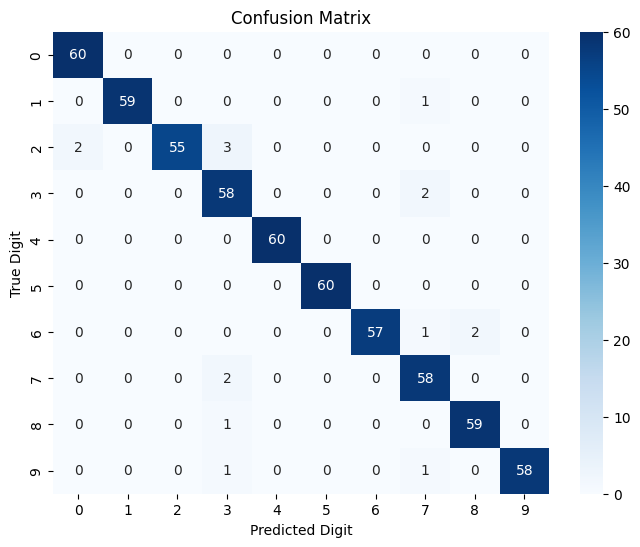

In [26]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted Digit")
plt.ylabel("True Digit")
plt.title("Confusion Matrix")
plt.show()

Question 3: Decoding

Decode Hidden State Sequence

In [27]:
def decode_hidden_states(file_path, model):

    mfcc = extract_mfcc(file_path)

    log_prob, state_sequence = model.decode(
        mfcc,
        algorithm='viterbi'
    )

    return log_prob, state_sequence

In [28]:
sample_file = test_files[3][0]

log_prob, states = decode_hidden_states(
    sample_file,
    hmm_models[3]
)

print("Viterbi Log Probability:", log_prob)
print("Most Probable Hidden State Sequence:")
print(states)

Viterbi Log Probability: -1049.5642273299438
Most Probable Hidden State Sequence:
[0 0 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2]


###Part II: Artificial Neural Networks (ANN)

In [29]:
!pip install librosa tensorflow scikit-learn -q

In [30]:
import os
import numpy as np
import librosa
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

MFCC Extraction

In [32]:
def extract_mfcc(file_path, n_mfcc=13):

    signal, sr = librosa.load(file_path, sr=None)

    mfcc = librosa.feature.mfcc(
        y=signal,
        sr=sr,
        n_mfcc=n_mfcc,
        n_fft=512,
        hop_length=160,
        win_length=400
    )

    return mfcc.T

In [33]:
digit_files = {i: [] for i in range(10)}

for file in os.listdir(DATASET_PATH):

    if file.endswith(".wav"):
        digit = int(file[0])
        digit_files[digit].append(os.path.join(DATASET_PATH, file))

In [34]:
train_files = {}
test_files = {}

for digit in range(10):

    train, test = train_test_split(
        digit_files[digit],
        test_size=0.2,
        random_state=42
    )

    train_files[digit] = train
    test_files[digit] = test

Prepare Frame-Level Training Data

In [35]:
X_train = []
y_train = []

for digit in range(10):

    for file_path in train_files[digit]:

        mfcc_seq = extract_mfcc(file_path)

        for frame in mfcc_seq:
            X_train.append(frame)
            y_train.append(digit)

X_train = np.array(X_train)
y_train = np.array(y_train)

print(X_train.shape)
print(y_train.shape)

(53714, 13)
(53714,)


Build Feedforward ANN

In [36]:
model = tf.keras.Sequential([

    tf.keras.layers.Dense(128, activation='relu', input_shape=(13,)),
    tf.keras.layers.Dense(64, activation='relu'),

    tf.keras.layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [37]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


Train ANN


In [38]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/20
756/756 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.4043 - loss: 2.1276 - val_accuracy: 0.0192 - val_loss: 3.3678
Epoch 2/20
756/756 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4993 - loss: 1.4256 - val_accuracy: 0.0197 - val_loss: 3.8374
Epoch 3/20
756/756 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5309 - loss: 1.3200 - val_accuracy: 0.0666 - val_loss: 3.0822
Epoch 4/20
756/756 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5555 - loss: 1.2492 - val_accuracy: 0.0557 - val_loss: 3.8693
Epoch 5/20
756/756 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5743 - loss: 1.1880 - val_accuracy: 0.0843 - val_loss: 3.2430
Epoch 6/20
756/756 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5856 - loss: 1.1519 - val_accuracy: 0.1221 - val_loss: 2.9916
Epoch 7/20
756/756 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.5991 - loss: 1.1101 - val_accuracy: 0.0771 - val_loss: 3.4213
Epoch 8/20
756/756 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6094 - loss: 1.0811 - val_accuracy: 0.

Sequence-Level Prediction Function

In [39]:
def predict_sequence(file_path, model):

    mfcc_seq = extract_mfcc(file_path)

    probs = model.predict(mfcc_seq, verbose=0)

    log_probs = np.log(probs + 1e-10)

    summed_log_probs = np.sum(log_probs, axis=0)

    predicted_digit = np.argmax(summed_log_probs)

    return predicted_digit, summed_log_probs

In [40]:
y_true = []
y_pred = []

for digit in range(10):

    for file_path in test_files[digit]:

        pred, _ = predict_sequence(file_path, model)

        y_true.append(digit)
        y_pred.append(pred)

Accuracy

In [41]:
accuracy = accuracy_score(y_true, y_pred)

print(f"ANN Test Accuracy: {accuracy*100:.2f}%")

ANN Test Accuracy: 91.67%


Confusion Matrix

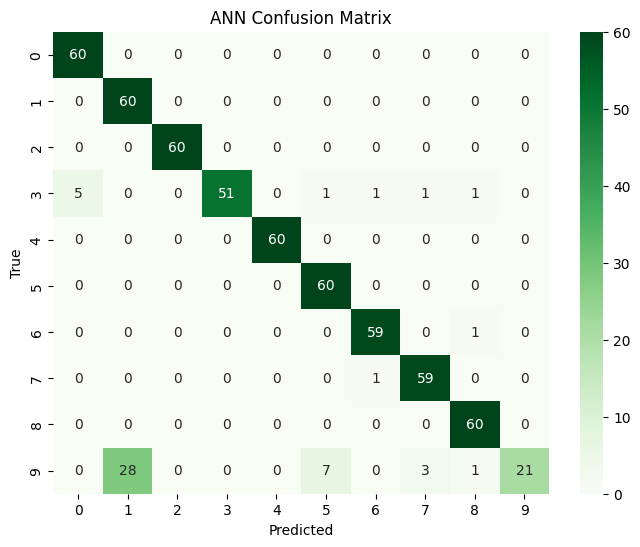

In [42]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("ANN Confusion Matrix")
plt.show()

###Question 5: Comparison

In [45]:
print("Model Comparison")
print("-------------------------")
print(f"HMM Accuracy : {hmm_accuracy*100:.2f}%")
print(f"ANN Accuracy : {accuracy*100:.2f}%")

Model Comparison
-------------------------
HMM Accuracy : 91.67%
ANN Accuracy : 91.67%
